# Best Model

### Installs

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn optuna torch torchvision torchaudio tqdm joblib

Device  : cuda
Run dir : runs\fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
pos_weight  : 27.58  (neg/pos ratio)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.9140      0.5161    47.0s
       2/8    0.7533      0.5785    45.6s
       3/8    0.6820      0.5810    46.1s
       4/8    0.6269      0.6237    45.9s
       5/8    0.5791      0.6690    46.1s
       6/8    0.5416      0.6731    46.8s
       7/8    0.5116      0.7066    47.9s
       8/8    0.4762      0.6954    47.1s
  [Trial  0] val_PR-AUC=0.7066  params={'hidden_dim': 256, 'lr': 0.0015751320499779737, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.8035 

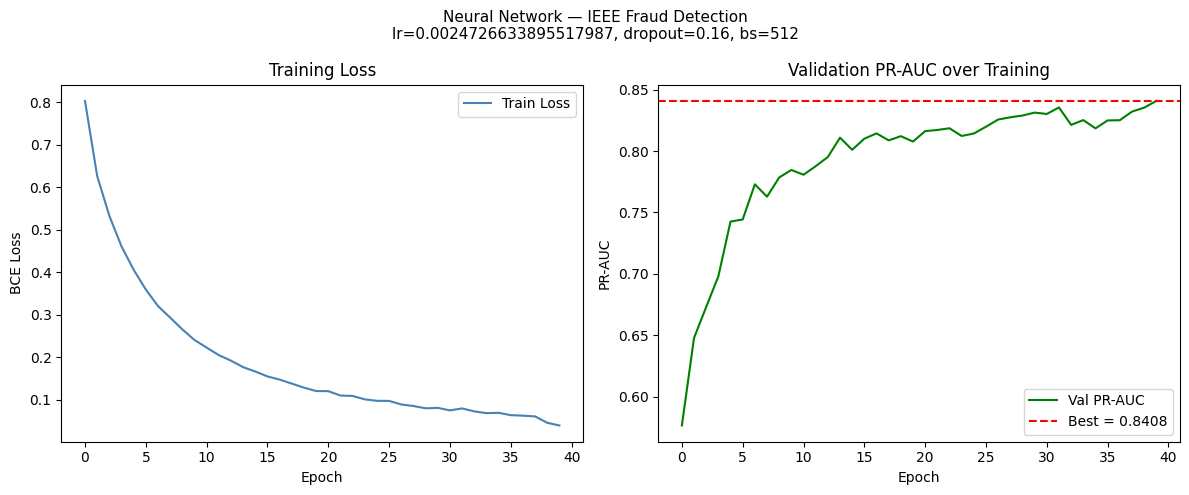

Training curves saved to runs\fraud_nn\nn_training_curves.png


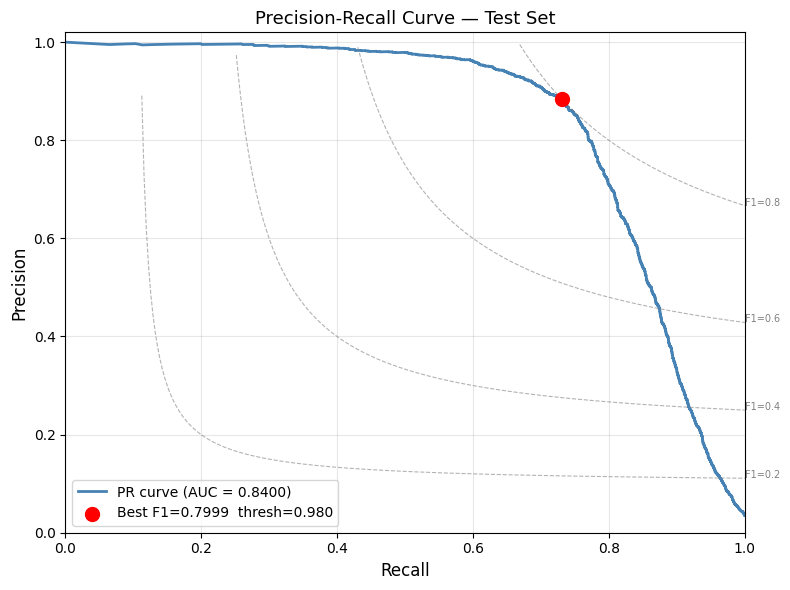

PR curve saved to runs\fraud_nn\pr_curve.png

  Final Results at best threshold = 0.980
  Test PR-AUC  : 0.8400
  Test F1      : 0.7999
  Test Recall  : 0.7309
  Test Precision: 0.8834
  Val  Recall  : 0.7222

Final metrics saved to runs\fraud_nn\final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       0.99      1.00      0.99     85482
       Fraud       0.88      0.73      0.80      3099

    accuracy                           0.99     88581
   macro avg       0.94      0.86      0.90     88581
weighted avg       0.99      0.99      0.99     88581

Model saved to runs\fraud_nn\nn_model.pt

  All outputs saved to: runs\fraud_nn/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [2]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - BCEWithLogitsLoss + pos_weight (class imbalance)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def get_pos_weight(y_series, device):
    n_neg = (y_series == 0).sum()
    n_pos = (y_series == 1).sum()
    return torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    pos_weight,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    pos_weight,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            pos_weight,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
        
    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    pos_weight = get_pos_weight(train_df[target], device)
    print(f"pos_weight  : {pos_weight.item():.2f}  (neg/pos ratio)")

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        pos_weight,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"{'=' * 60}\n")

    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_train = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    loader_val = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        pos_weight,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)
    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = f"lr={lr}, dropout={best_config['dropout']:.2f}, bs={batch_size}"
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    y_true, y_proba = get_predictions(model, loader_test)

    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    f1_scores = (
        2 * precision_pts[:-1] * recall_pts[:-1]
        / (precision_pts[:-1] + recall_pts[:-1] + 1e-8)
    )
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    best_recall = float(recall_pts[best_idx])
    best_precision = float(precision_pts[best_idx])

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        best_recall,
        best_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Best F1={best_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )
    test_recall = best_recall

    print(f"\n{'=' * 50}")
    print(f"  Final Results at best threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Test PR-AUC  : {test_pr:.4f}")
    print(f"  Test F1      : {best_f1:.4f}")
    print(f"  Test Recall  : {test_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall  : {val_recall:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": best_f1,
        "test_recall": test_recall,
        "test_precision": best_precision,
        "val_recall": val_recall,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_recall": test_recall,
        "val_recall": val_recall,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()

# Chosen final model

In [ ]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - Alpha-balanced FocalLoss (alpha + gamma tuned by Optuna)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
  - Threshold selected on validation set using F-beta (beta=2.0) to prioritise recall
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Alpha-balanced binary focal loss on raw logits.

    alpha:
        weight for positive class (fraud)
        higher alpha -> more emphasis on fraud examples

    gamma:
        focusing parameter; 0.0 => BCE
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = alpha_t * (1.0 - p_t).pow(self.gamma)

        loss = focal_weight * bce
        return loss.mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(cat, num)
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits encountered during training.")

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss encountered during training.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered during evaluation.")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


def find_best_fbeta_threshold(y_true, y_proba, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0

    beta2 = beta ** 2
    scores = (
        (1 + beta2) * precision[:-1] * recall[:-1]
        / (beta2 * precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = int(np.argmax(scores))
    return (
        float(thresholds[best_idx]),
        float(scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    use_pin_memory = (device.type == "cuda")

    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = FocalLoss(alpha=config["alpha"], gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)

        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "alpha": trial.suggest_float("alpha", 0.60, 0.95),
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        catch=(ValueError,),
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40
    beta_for_threshold = 2.0

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "alpha",
            "gamma",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  alpha = {best_config['alpha']:.3f}")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    use_pin_memory = (device.type == "cuda")
    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_val = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_test = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    if best_state is None:
        raise RuntimeError("Training failed: no valid checkpoint was produced.")

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)

    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Focal Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={batch_size}, alpha={best_config['alpha']:.2f}, "
        f"gamma={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    # Select threshold on validation only, using F-beta to prioritise recall
    val_y_true, val_proba = get_predictions(model, loader_val)
    best_thresh, val_best_fbeta, val_best_recall, val_best_precision = find_best_fbeta_threshold(
        val_y_true,
        val_proba,
        beta=beta_for_threshold,
    )

    # Final test evaluation using validation-selected threshold
    y_true, y_proba = get_predictions(model, loader_test)
    y_pred = (y_proba >= best_thresh).astype(int)

    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_precision = precision_score(y_true, y_pred, zero_division=0)
    test_f1 = f1_score(y_true, y_pred, zero_division=0)

    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        test_recall,
        test_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Test F1={test_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )

    print(f"\n{'=' * 50}")
    print(f"  Final Results at validation-selected threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Val  F{beta_for_threshold:.1f} : {val_best_fbeta:.4f}")
    print(f"  Val  Recall   : {val_best_recall:.4f}")
    print(f"  Val  Precision: {val_best_precision:.4f}")
    print(f"  Test F1       : {test_f1:.4f}")
    print(f"  Test Recall   : {test_recall:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "val_fbeta": val_best_fbeta,
        "val_recall": val_recall,
        "val_precision": val_best_precision,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()